# Load a MTRX image for Analysis
Use this notebook to load Scienta Omicron Matrix format SPM data. Your own code can be added to process the data. 

**Author**: Steven R. Schofield  
**Created**: April, 2026

In [1]:
# For file path operations
import os

In [2]:
# Path to data processing module
module_path_list = [
    '/Users/steven/academic-iCloud/Python/modules'        # CHANGE THIS TO YOUR OWN PATH WHERE YOU KEEP THESE PYTHON MODULES
] 

module_path = next((p for p in module_path_list if os.path.exists(p)), None)
if not module_path:
    exit("No valid module paths.")
else:
    print('module_path = {}'.format(module_path))
    print(os.listdir(module_path))

module_path = /Users/steven/academic-iCloud/Python/modules
['SRSML24', '.DS_Store', 'SRSCALCUTILS', 'SCT25']


In [3]:
# # Ensure modules are reloaded 
%load_ext autoreload
%autoreload 2

# Import standard modules
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps  # Import the new colormap module

# Add custom module path to list
sys.path.append(module_path)

# Import custom module
import SRSML24.data_prep as dp
import SRSML24.data_analysis as da

start_time = dp.current_datetime()

Current time 2026-04-27 15:34:50


In [4]:
# The working direcroryt should contain a subfolder 'mtrx' that contains the matrix image data. They can be in subfolders
working_directory = '/Users/steven/academic-iCloud/Python/modules/SRSML24/data/sample_data'      # CHANGE THIS TO YOUR OWN PATH WHERE YOU KEEP YOUR MTRX DATA
working_directory = '/Users/steven/Python-data-Hardeep/03-Oct-2025'
output_directory = os.path.join(working_directory, 'output')

In [5]:
job_data_path = dp.create_new_data_path(working_directory, output_directory, include_date=False)
mtrx_path = dp.create_new_data_path(working_directory, 'mtrx', include_date=False)

if not working_directory:
    exit("No valid data paths.")
else:
    print('Top   : {}'.format(working_directory))
    print('Read  : {}'.format(mtrx_path))
    print('Write : {}'.format(job_data_path))

Top   : /Users/steven/Python-data-Hardeep/03-Oct-2025
Read  : /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx
Write : /Users/steven/Python-data-Hardeep/03-Oct-2025/output


In [6]:
# Training data
mtrx_file_list, _ = dp.list_files_by_extension(mtrx_path,'Z_mtrx',verbose=False)

Found 350 files with extension 'Z_mtrx' in directory:
/Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx


In [7]:
for i, file in enumerate(mtrx_file_list):
    print(i, file)

0 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--100_1.Z_mtrx
1 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--101_1.Z_mtrx
2 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--101_2.Z_mtrx
3 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--102_1.Z_mtrx
4 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--103_1.Z_mtrx
5 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--104_1.Z_mtrx
6 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--104_2.Z_mtrx
7 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--105_1.Z_mtrx
8 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectrosco

In [8]:
mtrx_file = mtrx_file_list[204]
print('Working with image: {}'.format(mtrx_file))

# colormapname = 'viridis'
# colormapname = 'gray'
colormapname = 'gist_heat'


Working with image: /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--194_2.Z_mtrx


'default_2025Oct03-085731_STM-STM_Spectroscopy--194_2' — 2 scan directions loaded: FU, BU


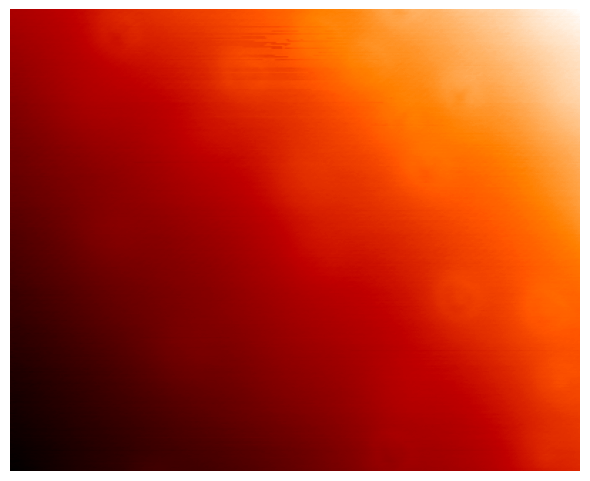

In [9]:
imgFU, imgBU, imgFD, imgBD, metadata = dp.load_image_for_processing(mtrx_file)

dp.display_image(imgFU,cmap=colormapname)

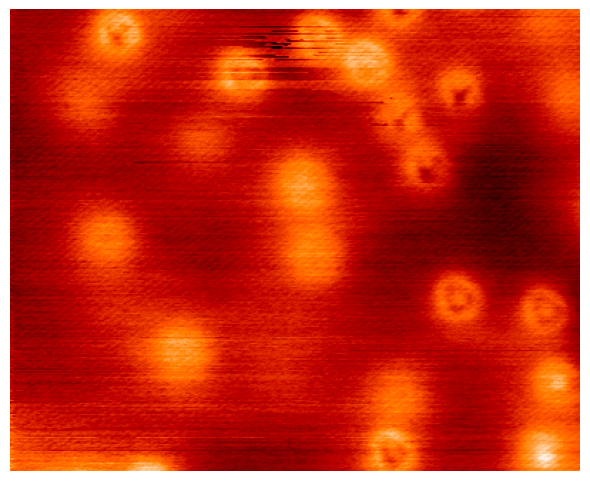

In [10]:
imgFU_flat = dp.flatten_image_data(imgFU, flatten_method='poly_xy')
#imgFU_flat = dp.flatten_image_data(imgFU, flatten_method='iterate_mask')  # default
#imgFU_flat = dp.flatten_image_data(imgFU, flatten_method='row_mean')
#imgFU_flat = dp.flatten_image_data(imgFU, flatten_method='row_mean_and_slope')

dp.display_image(imgFU_flat,cmap=colormapname)

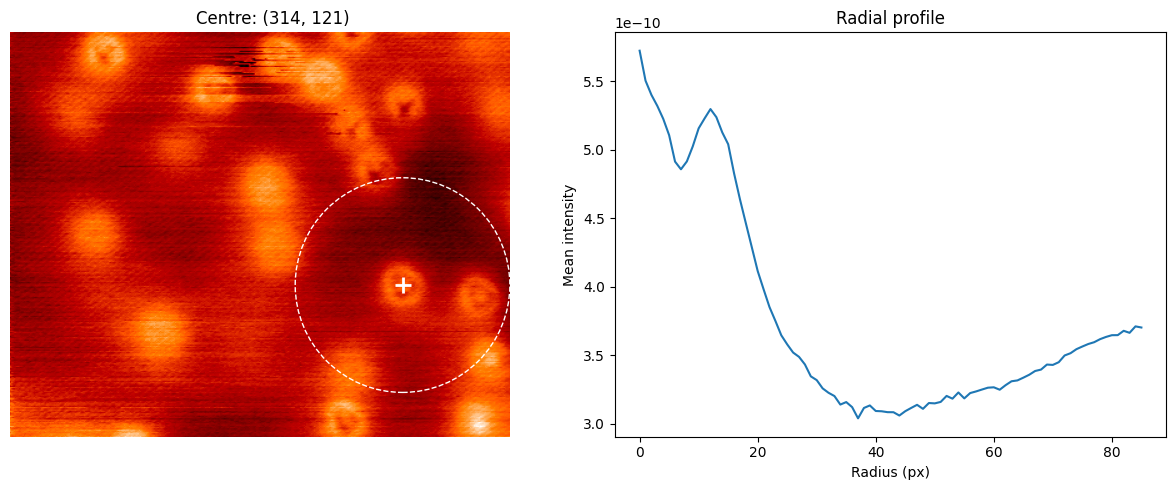

In [28]:
# Then pass them in directly
radii_1, profile_1 = da.radial_profile(imgFU_flat, center=(314, 121), cmap='gist_heat')

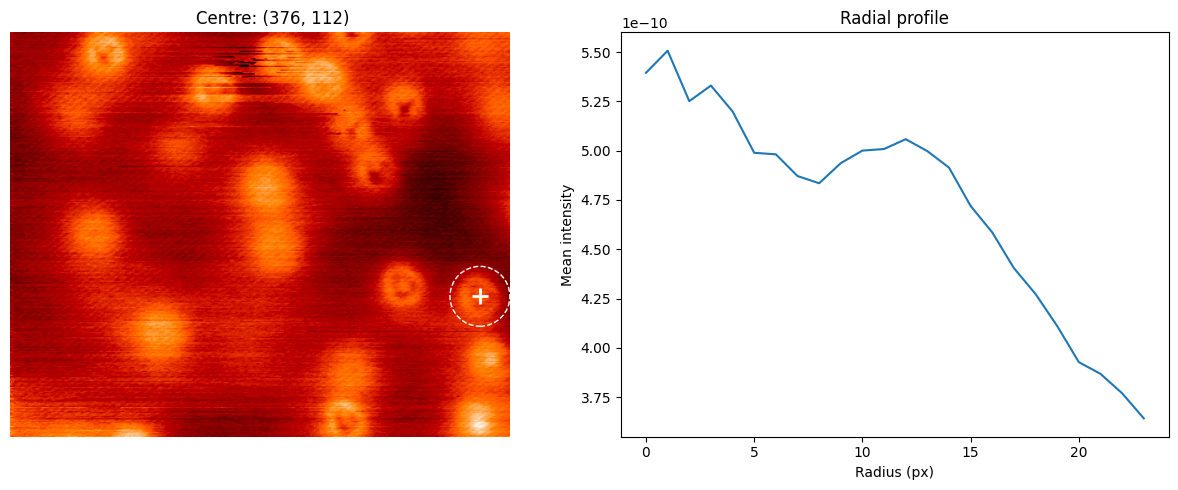

In [29]:
# Then pass them in directly
radii_2, profile_2 = da.radial_profile(imgFU_flat, center=(376, 112), cmap='gist_heat')

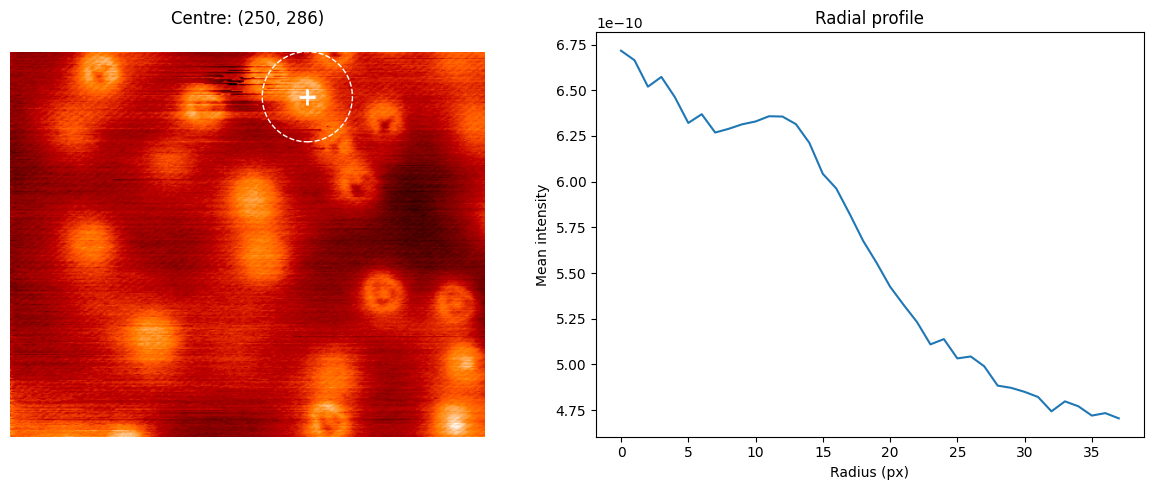

In [30]:
# Then pass them in directly
radii_3, profile_3 = da.radial_profile(imgFU_flat, center=(250, 286), cmap='gist_heat')

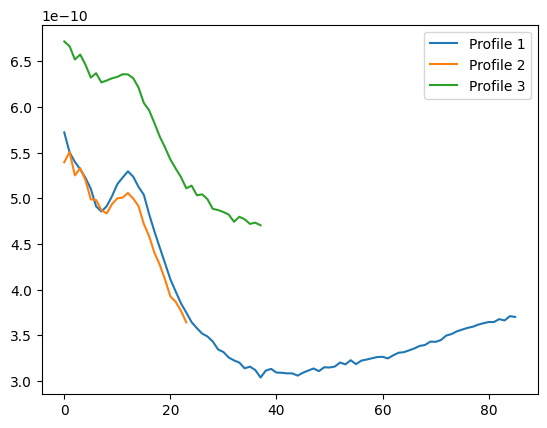

In [31]:
plt.plot(radii_1, profile_1, label="Profile 1")
plt.plot(radii_2, profile_2, label="Profile 2")
plt.plot(radii_3, profile_3, label="Profile 3")
plt.legend()